# Clusterización de artículos aplicables a forecast

Una vez identificados los artículos que aplican a forecast, el siguiente paso consiste en agruparlos según su comportamiento histórico de venta. El objetivo de esta etapa es clasificar los artículos en grupos homogéneos para posteriormente comparar modelos de predicción dentro de cada grupo y seleccionar el algoritmo con mejor desempeño.

La clusterización se basará en variables que describen el comportamiento de la demanda, tales como volumen vendido, frecuencia de venta, meses con venta, meses sin venta, variabilidad, intermitencia, recencia, tendencia y posible estacionalidad. Este enfoque permite diferenciar artículos de alta rotación, demanda estable, demanda intermitente, baja rotación o comportamiento variable.

Las variables iniciales propuestas para clusterizar son:

variables_cluster_final = [
    "total_unidades_vendidas_24m",(ok)
    "venta_promedio_mensual_24m",(ok)
    "conteo_facturas_24m",(ok)
    "cantidad_clientes_24m",(ok)
    "meses_con_venta_24m",(ok)
    "frecuencia_venta_24m_pct",(ok)
    "venta_promedio_reciente_last_6m",(ok)
    "ratio_venta_reciente_6m",(ok)
    "desviacion_std_venta_24m",(calcular)
    "coeficiente_variacion_venta_24m",(calcular)
    "venta_maxima_mensual_24m",(calcular)
    "venta_mediana_mensual_24m",(calcular)
    "porcentaje_meses_sin_venta_24m",(calcular)
    "max_meses_consecutivos_sin_venta",(calcular)
    "meses_desde_ultima_venta",(calcular)
    "pendiente_tendencia_24m"
]

Con estas variables se buscará capturar las dimensiones principales del comportamiento histórico de cada artículo: volumen, frecuencia, intermitencia, estabilidad, tendencia y recencia.

Posteriormente, se evaluarán modelos de clusterización como K-Means, Gaussian Mixture Models, Agglomerative Clustering y DBSCAN. La calidad de los clusters se analizará mediante métricas como Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index y análisis visual mediante PCA.

Una vez definidos los grupos, se compararán distintos modelos de forecast por cluster, tales como Naive Forecast, Moving Average, ETS, AutoARIMA, Croston, SBA, TSB, Prophet y modelos de Machine Learning como XGBoost o LightGBM. La selección del modelo ganador se realizará mediante métricas como WAPE, MAE, RMSE, Bias y riesgo estimado de quiebre o exceso de inventario.


In [51]:
from datetime import datetime
from sklearn.linear_model import LinearRegression

fecha_hoy = datetime.today().strftime("%Y-%m-%d")

nombre_archivo = f"dataframe_aplica_forecast_true_rev_{fecha_hoy}.csv"

print(nombre_archivo)

dataframe_aplica_forecast_true_rev_2026-07-10.csv


In [52]:
import numpy as np
import pandas as pd
#from sklearn.linear_model import LinearRegression

ruta_aplica_forecast=f"./Datos/dataframe_aplica_forecast_true_rev_{fecha_hoy}.csv"

df=pd.read_csv(ruta_aplica_forecast,
    sep=";"
)

In [53]:
import numpy as np
import pandas as pd
#from sklearn.linear_model import LinearRegression

# ============================================================
# 1. Identificar columnas mensuales de venta
# ============================================================
# Se excluyen columnas como venta_total_2024, venta_total_2025, etc.
# porque solo queremos columnas mensuales.
# ============================================================

columnas_venta_mensual = [
    col for col in df
    if col.startswith("venta_")
    and "total" not in col.lower()
    and "promedio" not in col.lower()
    and "estimada" not in col.lower()
    and "proyecto" not in col.lower()
    and "mensual" not in col.lower()
]

# Validar columnas encontradas
print("Columnas mensuales detectadas:")
print(columnas_venta_mensual)
print(f"Total columnas mensuales: {len(columnas_venta_mensual)}")

Columnas mensuales detectadas:
['venta_enero_2024', 'venta_febrero_2024', 'venta_marzo_2024', 'venta_abril_2024', 'venta_mayo_2024', 'venta_junio_2024', 'venta_julio_2024', 'venta_agosto_2024', 'venta_septiembre_2024', 'venta_octubre_2024', 'venta_noviembre_2024', 'venta_diciembre_2024', 'venta_enero_2025', 'venta_febrero_2025', 'venta_marzo_2025', 'venta_abril_2025', 'venta_mayo_2025', 'venta_junio_2025', 'venta_julio_2025', 'venta_agosto_2025', 'venta_septiembre_2025', 'venta_octubre_2025', 'venta_noviembre_2025', 'venta_diciembre_2025', 'venta_enero_2026', 'venta_febrero_2026', 'venta_marzo_2026', 'venta_abril_2026', 'venta_mayo_2026', 'venta_junio_2026', 'venta_julio_2026']
Total columnas mensuales: 31


In [54]:
# ============================================================
# 2. Asegurar que las columnas mensuales sean numéricas
# ============================================================

df[columnas_venta_mensual] = (
    df[columnas_venta_mensual]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

# ============================================================
# 3. Tomar últimos 24 meses disponibles
# ============================================================
# Esto permite que el cálculo sea dinámico aunque en el futuro
# existan nuevas columnas como venta_julio_2026, venta_agosto_2026, etc.
# ============================================================

columnas_venta_24m = columnas_venta_mensual[-24:]

print("Columnas usadas para análisis 24m:")
print(columnas_venta_24m)

Columnas usadas para análisis 24m:
['venta_agosto_2024', 'venta_septiembre_2024', 'venta_octubre_2024', 'venta_noviembre_2024', 'venta_diciembre_2024', 'venta_enero_2025', 'venta_febrero_2025', 'venta_marzo_2025', 'venta_abril_2025', 'venta_mayo_2025', 'venta_junio_2025', 'venta_julio_2025', 'venta_agosto_2025', 'venta_septiembre_2025', 'venta_octubre_2025', 'venta_noviembre_2025', 'venta_diciembre_2025', 'venta_enero_2026', 'venta_febrero_2026', 'venta_marzo_2026', 'venta_abril_2026', 'venta_mayo_2026', 'venta_junio_2026', 'venta_julio_2026']


In [55]:
ventas_24m = df[columnas_venta_24m]

In [56]:
# ============================================================
# 4. Cálculo de variables matemáticas de comportamiento histórico
# ============================================================
# En esta sección se calculan métricas que describen el comportamiento
# histórico de venta de cada artículo durante los últimos 24 meses.
#
# Estas variables serán utilizadas posteriormente para clusterizar los
# artículos aplicables a forecast según patrones matemáticos de demanda:
# volumen, variabilidad, intermitencia, concentración de picos y estabilidad.
# ============================================================

# Crear matriz de ventas mensuales de los últimos 24 meses
ventas_24m = df[columnas_venta_24m].copy()

# Asegurar que todas las columnas de venta sean numéricas
ventas_24m = (
    ventas_24m
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

# ============================================================
# 4.1 Métricas base de distribución mensual
# ============================================================

# ------------------------------------------------------------
# Promedio mensual de venta en los últimos 24 meses
# ------------------------------------------------------------
# Representa el nivel promedio de demanda mensual del artículo.
# Se utiliza como base para calcular métricas relativas como
# coeficiente de variación, ratio máximo/promedio y umbral de picos.
# ------------------------------------------------------------

promedio_venta_24m = ventas_24m.mean(axis=1)

# ------------------------------------------------------------
# Desviación estándar de venta mensual
# ------------------------------------------------------------
# Mide qué tanto varían las ventas mensuales respecto al promedio.
# Un valor alto indica demanda más irregular o con mayor dispersión.
# ------------------------------------------------------------

desviacion_std_venta_24m = ventas_24m.std(axis=1)

df["desviacion_std_venta_24m"] = desviacion_std_venta_24m

# ------------------------------------------------------------
# Coeficiente de variación de venta
# ------------------------------------------------------------
# Fórmula:
# coeficiente_variacion = desviación estándar / promedio mensual
#
# Permite comparar la variabilidad entre artículos con diferentes
# niveles de venta. Si el promedio es 0, se asigna 0 para evitar
# divisiones indefinidas.
# ------------------------------------------------------------

df["coeficiente_variacion_venta_24m"] = np.where(
    promedio_venta_24m > 0,
    desviacion_std_venta_24m / promedio_venta_24m,
    0
)

# ------------------------------------------------------------
# Venta máxima mensual
# ------------------------------------------------------------
# Identifica el mayor volumen vendido en un solo mes dentro del
# período de análisis. Ayuda a detectar posibles picos de demanda.
# ------------------------------------------------------------

df["venta_maxima_mensual_24m"] = ventas_24m.max(axis=1)

# ------------------------------------------------------------
# Venta mediana mensual
# ------------------------------------------------------------
# Representa el valor central de la venta mensual.
# Es menos sensible a picos extremos que el promedio.
# ------------------------------------------------------------

df["venta_mediana_mensual_24m"] = ventas_24m.median(axis=1)

# ------------------------------------------------------------
# Rango intercuartílico de venta, IQR
# ------------------------------------------------------------
# Fórmula:
# IQR = percentil 75 - percentil 25
#
# Mide la dispersión central de las ventas, reduciendo el efecto
# de valores extremos o picos atípicos.
# ------------------------------------------------------------

df["iqr_venta_24m"] = (
    ventas_24m.quantile(0.75, axis=1) -
    ventas_24m.quantile(0.25, axis=1)
)

# ============================================================
# 4.2 Métricas de picos y concentración de demanda
# ============================================================

# ------------------------------------------------------------
# Umbral de pico de venta
# ------------------------------------------------------------
# Se define como:
# umbral_pico = promedio mensual + desviación estándar
#
# Un mes se considera pico cuando su venta mensual supera este umbral.
# Esta métrica ayuda a identificar artículos con ventas concentradas
# en meses puntuales o eventos de demanda atípicamente altos.
# ------------------------------------------------------------

umbral_pico = pd.DataFrame(
    np.repeat(
        (promedio_venta_24m + desviacion_std_venta_24m).values.reshape(-1, 1),
        ventas_24m.shape[1],
        axis=1
    ),
    index=ventas_24m.index,
    columns=ventas_24m.columns
)

# ------------------------------------------------------------
# Cantidad de meses pico en los últimos 24 meses
# ------------------------------------------------------------
# Cuenta cuántos meses superaron el umbral de pico definido.
# Un valor alto puede indicar demanda irregular, estacionalidad
# potencial o concentración de ventas en ciertos períodos.
# ------------------------------------------------------------

df["cantidad_meses_pico_24m"] = (ventas_24m > umbral_pico).sum(axis=1)

# ------------------------------------------------------------
# Ratio venta máxima vs promedio mensual
# ------------------------------------------------------------
# Fórmula:
# ratio = venta máxima mensual / promedio mensual
#
# Permite medir qué tan extremo fue el mayor mes de venta en relación
# con el comportamiento promedio del artículo.
# ------------------------------------------------------------

df["ratio_max_vs_promedio_24m"] = np.where(
    promedio_venta_24m > 0,
    df["venta_maxima_mensual_24m"] / promedio_venta_24m,
    0
)

# ============================================================
# 4.3 Métricas de intermitencia y frecuencia de demanda
# ============================================================

# ------------------------------------------------------------
# Porcentaje de meses sin venta
# ------------------------------------------------------------
# Fórmula:
# meses sin venta / total de meses analizados * 100
#
# Mide qué proporción del período el artículo no tuvo movimiento.
# Es una variable clave para identificar demanda intermitente.
# ------------------------------------------------------------

df["porcentaje_meses_sin_venta_24m"] = (
    ventas_24m.eq(0).sum(axis=1) / len(columnas_venta_24m)
) * 100

# ------------------------------------------------------------
# Venta promedio en meses con venta
# ------------------------------------------------------------
# Fórmula:
# total vendido / cantidad de meses con venta
#
# Esta métrica calcula cuánto se vende en promedio cuando el artículo
# realmente tiene demanda, excluyendo los meses en cero.
#
# Es útil para diferenciar artículos que venden poco todos los meses
# de artículos que venden ocasionalmente, pero en cantidades relevantes.
# ------------------------------------------------------------

meses_con_venta_calculado = ventas_24m.gt(0).sum(axis=1)

df["venta_promedio_meses_con_venta_24m"] = np.where(
    meses_con_venta_calculado > 0,
    ventas_24m.sum(axis=1) / meses_con_venta_calculado,
    0
)

# ------------------------------------------------------------
# ADI, Average Demand Interval
# ------------------------------------------------------------
# Fórmula:
# ADI = total de períodos / meses con venta
#
# Mide cada cuántos meses aparece demanda.
# Un ADI cercano a 1 indica venta frecuente.
# Un ADI alto indica demanda más intermitente.
#
# Aunque es una variable relacionada con frecuencia_venta_24m_pct,
# se calcula porque es una métrica reconocida para analizar demanda
# intermitente y puede ser útil para justificar metodológicamente
# modelos como Croston, SBA o TSB.
# ------------------------------------------------------------

df["adi_24m"] = np.where(
    df["meses_con_venta_24m"] > 0,
    24 / df["meses_con_venta_24m"],
    24
)

# ============================================================
# 4.4 Validación rápida de variables calculadas
# ============================================================

variables_calculadas_cluster = [
    "desviacion_std_venta_24m",
    "coeficiente_variacion_venta_24m",
    "venta_maxima_mensual_24m",
    "venta_mediana_mensual_24m",
    "iqr_venta_24m",
    "cantidad_meses_pico_24m",
    "ratio_max_vs_promedio_24m",
    "porcentaje_meses_sin_venta_24m",
    "venta_promedio_meses_con_venta_24m",
    "adi_24m"
]

df[variables_calculadas_cluster].describe().T

C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_16148\1413844741.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["desviacion_std_venta_24m"] = desviacion_std_venta_24m
C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_16148\1413844741.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["coeficiente_variacion_venta_24m"] = np.where(
C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_16148\1413844741.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,count,mean,std,min,25%,50%,75%,max
desviacion_std_venta_24m,429.0,3248.854417,23008.275475,0.717282,2.062431,4.618606,20.615484,3.338848e+05
coeficiente_variacion_venta_24m,429.0,1.684133,0.527668,0.459488,1.301370,1.649746,2.035446,3.962422e+00
venta_maxima_mensual_24m,429.0,12880.499161,93070.700022,2.000000,8.000000,17.000000,75.000000,1.347209e+06
venta_mediana_mensual_24m,429.0,2216.683240,16907.573637,0.000000,0.000000,0.000000,2.000000,2.263682e+05
iqr_venta_24m,429.0,3786.920134,26164.197705,0.250000,1.250000,3.250000,15.000000,3.164555e+05
cantidad_meses_pico_24m,429.0,3.452214,1.369110,1.000000,3.000000,3.000000,4.000000,1.000000e+01
ratio_max_vs_promedio_24m,429.0,6.385784,2.741754,2.184996,4.460906,5.760000,7.964602,1.955792e+01
porcentaje_meses_sin_venta_24m,429.0,51.855089,20.618010,0.000000,37.500000,58.333333,70.833333,7.500000e+01
venta_promedio_meses_con_venta_24m,429.0,4008.525473,27579.666563,1.272727,3.200000,6.000000,23.625000,3.446273e+05
adi_24m,429.0,2.464429,0.948255,1.000000,1.600000,2.400000,3.428571,4.000000e+00


Funciones auxiliares para describir el comportamiento histórico de venta

En esta sección se definen funciones auxiliares para calcular métricas adicionales sobre el historial mensual de ventas de cada artículo. Estas funciones permiten capturar características que no siempre se obtienen con métricas agregadas simples, como la duración de períodos sin venta, la recencia de la última venta, la tendencia general de la demanda, la concentración de picos, la repetición de patrones estacionales entre años y la variabilidad del tamaño de venta cuando existe demanda.

Estas variables serán utilizadas posteriormente como insumos para la clusterización de artículos aplicables a forecast, con el objetivo de agrupar productos que presenten comportamientos matemáticos similares de demanda histórica.

In [57]:
# ============================================================
# 5. Funciones auxiliares para comportamiento histórico de venta
# ============================================================
# En esta sección se definen funciones que serán aplicadas fila por fila
# sobre las ventas mensuales de los últimos 24 meses.
#
# Cada fila representa el historial mensual de venta de un artículo.
# Estas funciones permiten calcular variables adicionales para describir:
#
# 1. Intermitencia de la demanda.
# 2. Recencia de la última venta.
# 3. Tendencia histórica de venta.
# 4. Concentración de picos.
# 5. Posible estacionalidad.
# 6. Variabilidad en meses con venta.
# ============================================================


# ============================================================
# 5.1 Máxima racha de meses consecutivos sin venta
# ============================================================

def calcular_max_meses_consecutivos_sin_venta(fila):
    """
    Calcula la mayor cantidad de meses consecutivos con venta igual a cero.

    Esta métrica permite identificar artículos con períodos prolongados
    sin movimiento de venta, lo cual es útil para detectar demanda
    intermitente o irregular.

    Parámetros:
    fila: Serie o lista con ventas mensuales del artículo.

    Retorna:
    int: mayor racha consecutiva de meses sin venta.
    """

    max_racha = 0
    racha_actual = 0

    for valor in fila:
        if valor == 0:
            racha_actual += 1
            max_racha = max(max_racha, racha_actual)
        else:
            racha_actual = 0

    return max_racha


# ============================================================
# 5.2 Meses desde la última venta
# ============================================================

def calcular_meses_desde_ultima_venta(fila):
    """
    Calcula cuántos meses han transcurrido desde la última venta registrada.

    La función recorre el historial de ventas desde el mes más reciente
    hacia atrás. Si encuentra una venta mayor a cero, devuelve cuántos
    meses han pasado desde ese evento.

    Si el artículo no tuvo ventas en todo el período analizado,
    devuelve la longitud total de la serie.

    Parámetros:
    fila: Serie o lista con ventas mensuales del artículo.

    Retorna:
    int: cantidad de meses desde la última venta.
    """

    valores = list(fila)

    for i, valor in enumerate(reversed(valores)):
        if valor > 0:
            return i

    return len(valores)


# ============================================================
# 5.3 Pendiente de tendencia de venta
# ============================================================

def calcular_pendiente_tendencia(fila):
    """
    Calcula la pendiente de tendencia de la venta usando regresión lineal simple.

    La función ajusta una línea recta sobre la serie mensual de ventas.
    La pendiente de esa línea resume la dirección general del comportamiento
    de la demanda.

    Interpretación:
    - Pendiente positiva: tendencia creciente.
    - Pendiente cercana a cero: comportamiento estable.
    - Pendiente negativa: tendencia decreciente.

    Parámetros:
    fila: Serie o lista con ventas mensuales del artículo.

    Retorna:
    float: pendiente de la línea de tendencia.
    """

    y = np.array(fila, dtype=float)

    # Si no hubo ventas en todo el período, no existe tendencia evaluable.
    if np.sum(y) == 0:
        return 0

    # Crear eje temporal: 0, 1, 2, ..., n meses
    x = np.arange(len(y)).reshape(-1, 1)

    modelo = LinearRegression()
    modelo.fit(x, y)

    return modelo.coef_[0]


# ============================================================
# 5.4 Índice de concentración de picos
# ============================================================

def calcular_indice_concentracion_picos_24m(fila):
    """
    Calcula un índice de concentración de ventas en los meses de mayor demanda.

    Fórmula:
    índice = promedio de los 3 meses más altos / promedio mensual general

    Esta métrica no confirma estacionalidad. Su objetivo es medir si la venta
    se concentra en pocos meses o si se distribuye de manera más estable
    a lo largo del tiempo.

    Interpretación sugerida:
    - Cercano a 1: ventas relativamente estables.
    - Entre 1.5 y 3: presencia moderada de picos.
    - Mayor a 3: alta concentración de demanda en pocos meses.

    Parámetros:
    fila: Serie o lista con ventas mensuales del artículo.

    Retorna:
    float: índice de concentración de picos.
    """

    valores = np.array(fila, dtype=float)
    promedio = valores.mean()

    if promedio == 0:
        return 0

    top_3_promedio = np.sort(valores)[-3:].mean()

    return top_3_promedio / promedio


# ============================================================
# 5.5 Correlación estacional entre dos años
# ============================================================

def calcular_correlacion_estacional_12m(fila):
    """
    Calcula una señal de posible estacionalidad comparando el patrón mensual
    de un año contra el patrón mensual del siguiente año.

    La función compara los primeros 12 meses contra los siguientes 12 meses.
    Una correlación alta indica que los meses de mayor y menor venta tienden
    a repetirse entre años.

    Esta métrica debe interpretarse como una señal preliminar de estacionalidad,
    especialmente cuando solo se tienen 24 meses de historial.

    Interpretación sugerida:
    - >= 0.70: posible estacionalidad fuerte.
    - 0.40 a 0.70: posible estacionalidad moderada.
    - 0.20 a 0.40: señal débil.
    - < 0.20: sin patrón estacional claro.

    Parámetros:
    fila: Serie o lista con ventas mensuales del artículo.

    Retorna:
    float: correlación entre el patrón mensual del año 1 y año 2.
    """

    ventas = np.array(fila, dtype=float)

    # Validar que existan al menos 24 meses para comparar dos ciclos anuales.
    if len(ventas) < 24:
        return np.nan

    # Separar los primeros 12 meses y los siguientes 12 meses.
    anio_1 = ventas[:12]
    anio_2 = ventas[12:24]

    # Si ambos años no tienen ventas, no hay patrón estacional evaluable.
    if anio_1.sum() == 0 and anio_2.sum() == 0:
        return 0

    # Si alguno de los dos años no tiene variación, la correlación no es válida.
    if np.std(anio_1) == 0 or np.std(anio_2) == 0:
        return 0

    correlacion = np.corrcoef(anio_1, anio_2)[0, 1]

    return correlacion


# ============================================================
# 5.6 Coeficiente de variación solo en meses con venta
# ============================================================

def calcular_cv_meses_con_venta(fila):
    """
    Calcula el coeficiente de variación considerando únicamente los meses
    donde sí hubo venta.

    A diferencia del coeficiente de variación general, esta métrica excluye
    los meses en cero. Su objetivo es medir qué tan variable es el tamaño
    de la venta cuando existe demanda.

    Esto permite diferenciar entre:
    - Artículos intermitentes pero con ventas de tamaño estable.
    - Artículos intermitentes con ventas altamente irregulares.

    Fórmula:
    CV meses con venta = desviación estándar de meses positivos /
                         promedio de meses positivos

    Parámetros:
    fila: Serie o lista con ventas mensuales del artículo.

    Retorna:
    float: coeficiente de variación en meses con venta.
    """

    valores = np.array(fila, dtype=float)
    valores_positivos = valores[valores > 0]

    if len(valores_positivos) == 0:
        return 0

    promedio = valores_positivos.mean()

    if promedio == 0:
        return 0

    return valores_positivos.std() / promedio

In [58]:
# ============================================================
# 6. Aplicación de funciones auxiliares al DataFrame
# ============================================================
# En este bloque se aplican las funciones auxiliares definidas previamente
# sobre la matriz de ventas de los últimos 24 meses.
#
# El objetivo es generar nuevas variables matemáticas que describan
# el comportamiento histórico de venta de cada artículo.
# ============================================================


# ============================================================
# 6.1 Preparar matriz de ventas 24M
# ============================================================
# Se asegura que todas las columnas mensuales sean numéricas.
# Los valores no convertibles se reemplazan por NaN y luego por 0.
# ============================================================

ventas_24m = (
    ventas_24m
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)


# ============================================================
# 6.2 Crear DataFrame auxiliar para nuevas variables
# ============================================================
# Se utiliza un DataFrame auxiliar para evitar fragmentar el DataFrame
# original al insertar muchas columnas una por una.
# ============================================================

df_variables_cluster = pd.DataFrame(index=df.index)


# ============================================================
# 6.3 Calcular variables de intermitencia y recencia
# ============================================================

# Mayor cantidad de meses consecutivos sin venta.
df_variables_cluster["max_meses_consecutivos_sin_venta"] = ventas_24m.apply(
    calcular_max_meses_consecutivos_sin_venta,
    axis=1
)

# Cantidad de meses transcurridos desde la última venta.
df_variables_cluster["meses_desde_ultima_venta"] = ventas_24m.apply(
    calcular_meses_desde_ultima_venta,
    axis=1
)


# ============================================================
# 6.4 Calcular variables de tendencia y concentración
# ============================================================

# Pendiente de la tendencia histórica de venta.
# Valor positivo: tendencia creciente.
# Valor negativo: tendencia decreciente.
df_variables_cluster["pendiente_tendencia_24m"] = ventas_24m.apply(
    calcular_pendiente_tendencia,
    axis=1
)

# Índice de concentración de ventas en los 3 meses más altos.
# Mide presencia de picos, no estacionalidad por sí sola.
df_variables_cluster["indice_concentracion_picos_24m"] = ventas_24m.apply(
    calcular_indice_concentracion_picos_24m,
    axis=1
)


# ============================================================
# 6.5 Calcular señal de estacionalidad
# ============================================================

# Correlación entre el patrón mensual del primer año y el segundo año.
# Una correlación alta sugiere posible repetición estacional.
df_variables_cluster["correlacion_estacional_12m"] = ventas_24m.apply(
    calcular_correlacion_estacional_12m,
    axis=1
)


# ============================================================
# 6.6 Calcular variabilidad en meses con venta
# ============================================================

# Coeficiente de variación calculado únicamente en meses con venta positiva.
# Permite medir si el tamaño de la demanda es estable cuando sí existe venta.
df_variables_cluster["cv_meses_con_venta_24m"] = ventas_24m.apply(
    calcular_cv_meses_con_venta,
    axis=1
)


# ============================================================
# 6.7 Agregar variables calculadas al DataFrame principal
# ============================================================
# Se concatenan todas las columnas nuevas de una sola vez para evitar
# warnings de fragmentación y mejorar el rendimiento del DataFrame.
# ============================================================

df = pd.concat([df, df_variables_cluster], axis=1).copy()

In [59]:
variables_calculadas_cluster = [
    # ========================================================
    # Variables de distribución mensual
    # ========================================================
    "desviacion_std_venta_24m",
    "coeficiente_variacion_venta_24m",
    "venta_maxima_mensual_24m",
    "venta_mediana_mensual_24m",
    "iqr_venta_24m",

    # ========================================================
    # Variables de picos y concentración de demanda
    # ========================================================
    "cantidad_meses_pico_24m",
    "ratio_max_vs_promedio_24m",
    "indice_concentracion_picos_24m",

    # ========================================================
    # Variables de intermitencia y frecuencia
    # ========================================================
    "porcentaje_meses_sin_venta_24m",
    "venta_promedio_meses_con_venta_24m",
    "adi_24m",
    "max_meses_consecutivos_sin_venta",

    # ========================================================
    # Variables de recencia
    # ========================================================
    "meses_desde_ultima_venta",

    # ========================================================
    # Variables de tendencia
    # ========================================================
    "pendiente_tendencia_24m",

    # ========================================================
    # Variables de estacionalidad
    # ========================================================
    "correlacion_estacional_12m",

    # ========================================================
    # Variables de variabilidad en meses activos
    # ========================================================
    "cv_meses_con_venta_24m"
]

df[
    [
        "codigo_articulo",
        "descripcion_completa",
        *variables_calculadas_cluster
    ]
].head()

,codigo_articulo,descripcion_completa,desviacion_std_venta_24m,coeficiente_variacion_venta_24m,venta_maxima_mensual_24m,venta_mediana_mensual_24m,iqr_venta_24m,cantidad_meses_pico_24m,ratio_max_vs_promedio_24m,indice_concentracion_picos_24m,porcentaje_meses_sin_venta_24m,venta_promedio_meses_con_venta_24m,adi_24m,max_meses_consecutivos_sin_venta,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,306.649306,0.670028,1000.00,454.000,345.5000,4,2.184996,2.124545,12.500000,523.047619,1.142857,2,0,14.580870,-0.695503,0.501450
1,W8,"Cinta para husos, Habasit, W-8",333884.750067,1.367758,1347209.33,91542.875,316455.5400,4,5.518838,3.811150,29.166667,344627.337059,1.411765,2,1,-5326.251196,-0.275883,0.989061
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",134.329877,1.566210,491.45,32.705,59.7900,2,5.730026,4.558292,20.833333,108.337895,1.263158,2,1,-0.823330,-0.224816,1.285581
3,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",62.414839,1.105845,189.00,52.500,95.3325,3,3.348639,3.001727,20.833333,75.254444,1.333333,2,0,0.421261,-0.271689,0.641090
4,20004 1 1/2E,Grapa metal.caja 25 unid.p/banda 7/16''-11/16'...,35.976416,1.481019,118.00,5.000,26.2500,5,4.857633,4.075472,20.833333,30.684211,1.263158,1,1,-0.102174,-0.248651,1.206553


In [60]:
df[variables_calculadas_cluster].describe().T

,count,mean,std,min,25%,50%,75%,max
desviacion_std_venta_24m,429.0,3248.854417,23008.275475,0.717282,2.062431,4.618606,20.615484,3.338848e+05
coeficiente_variacion_venta_24m,429.0,1.684133,0.527668,0.459488,1.301370,1.649746,2.035446,3.962422e+00
venta_maxima_mensual_24m,429.0,12880.499161,93070.700022,2.000000,8.000000,17.000000,75.000000,1.347209e+06
venta_mediana_mensual_24m,429.0,2216.683240,16907.573637,0.000000,0.000000,0.000000,2.000000,2.263682e+05
iqr_venta_24m,429.0,3786.920134,26164.197705,0.250000,1.250000,3.250000,15.000000,3.164555e+05
cantidad_meses_pico_24m,429.0,3.452214,1.369110,1.000000,3.000000,3.000000,4.000000,1.000000e+01
ratio_max_vs_promedio_24m,429.0,6.385784,2.741754,2.184996,4.460906,5.760000,7.964602,1.955792e+01
indice_concentracion_picos_24m,429.0,4.503052,1.208905,1.782897,3.520000,4.517007,5.469091,7.338583e+00
porcentaje_meses_sin_venta_24m,429.0,51.855089,20.618010,0.000000,37.500000,58.333333,70.833333,7.500000e+01
venta_promedio_meses_con_venta_24m,429.0,4008.525473,27579.666563,1.272727,3.200000,6.000000,23.625000,3.446273e+05


In [61]:
ventas_variables_cluster_all=[
    "total_unidades_vendidas_24m",#(ok)
    "venta_promedio_mensual_24m",#(ok)
    "conteo_facturas_24m",#(ok)
    "cantidad_clientes_24m",#(ok)
    "meses_con_venta_24m",#(ok)
    "frecuencia_venta_24m_pct",#(ok)
    "venta_promedio_reciente_last_6m",#(ok)
    "ratio_venta_reciente_6m",#(ok)
    "desviacion_std_venta_24m",
    "coeficiente_variacion_venta_24m",
    "venta_maxima_mensual_24m",
    "venta_mediana_mensual_24m",
    "iqr_venta_24m",
    "cantidad_meses_pico_24m",
    "ratio_max_vs_promedio_24m",
    "indice_concentracion_picos_24m",
    "porcentaje_meses_sin_venta_24m",
    "venta_promedio_meses_con_venta_24m",
    "adi_24m",
    "max_meses_consecutivos_sin_venta",
    "meses_desde_ultima_venta",
    "pendiente_tendencia_24m",
    "correlacion_estacional_12m",
    "cv_meses_con_venta_24m"
]
df_cluser=df[
    [
        "codigo_articulo",
        "descripcion_completa",
        *ventas_variables_cluster_all
    ]
].head()

In [62]:
df_cluser.head()

,codigo_articulo,descripcion_completa,total_unidades_vendidas_24m,venta_promedio_mensual_24m,conteo_facturas_24m,cantidad_clientes_24m,meses_con_venta_24m,frecuencia_venta_24m_pct,venta_promedio_reciente_last_6m,ratio_venta_reciente_6m,...,ratio_max_vs_promedio_24m,indice_concentracion_picos_24m,porcentaje_meses_sin_venta_24m,venta_promedio_meses_con_venta_24m,adi_24m,max_meses_consecutivos_sin_venta,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,11165.00,465.208333,66,4,21,87.50,385.500000,0.828661,...,2.184996,2.124545,12.500000,523.047619,1.142857,2,0,14.580870,-0.695503,0.501450
1,W8,"Cinta para husos, Habasit, W-8",5975816.38,248992.349167,56,6,17,70.83,240040.970000,0.964050,...,5.518838,3.811150,29.166667,344627.337059,1.411765,2,1,-5326.251196,-0.275883,0.989061
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",2185.47,91.061250,48,18,19,79.17,43.551667,0.478268,...,5.730026,4.558292,20.833333,108.337895,1.263158,2,1,-0.823330,-0.224816,1.285581
3,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",1370.58,57.107500,45,21,18,75.00,67.201667,1.176757,...,3.348639,3.001727,20.833333,75.254444,1.333333,2,0,0.421261,-0.271689,0.641090
4,20004 1 1/2E,Grapa metal.caja 25 unid.p/banda 7/16''-11/16'...,588.00,24.500000,32,9,19,79.17,18.666667,0.761905,...,4.857633,4.075472,20.833333,30.684211,1.263158,1,1,-0.102174,-0.248651,1.206553


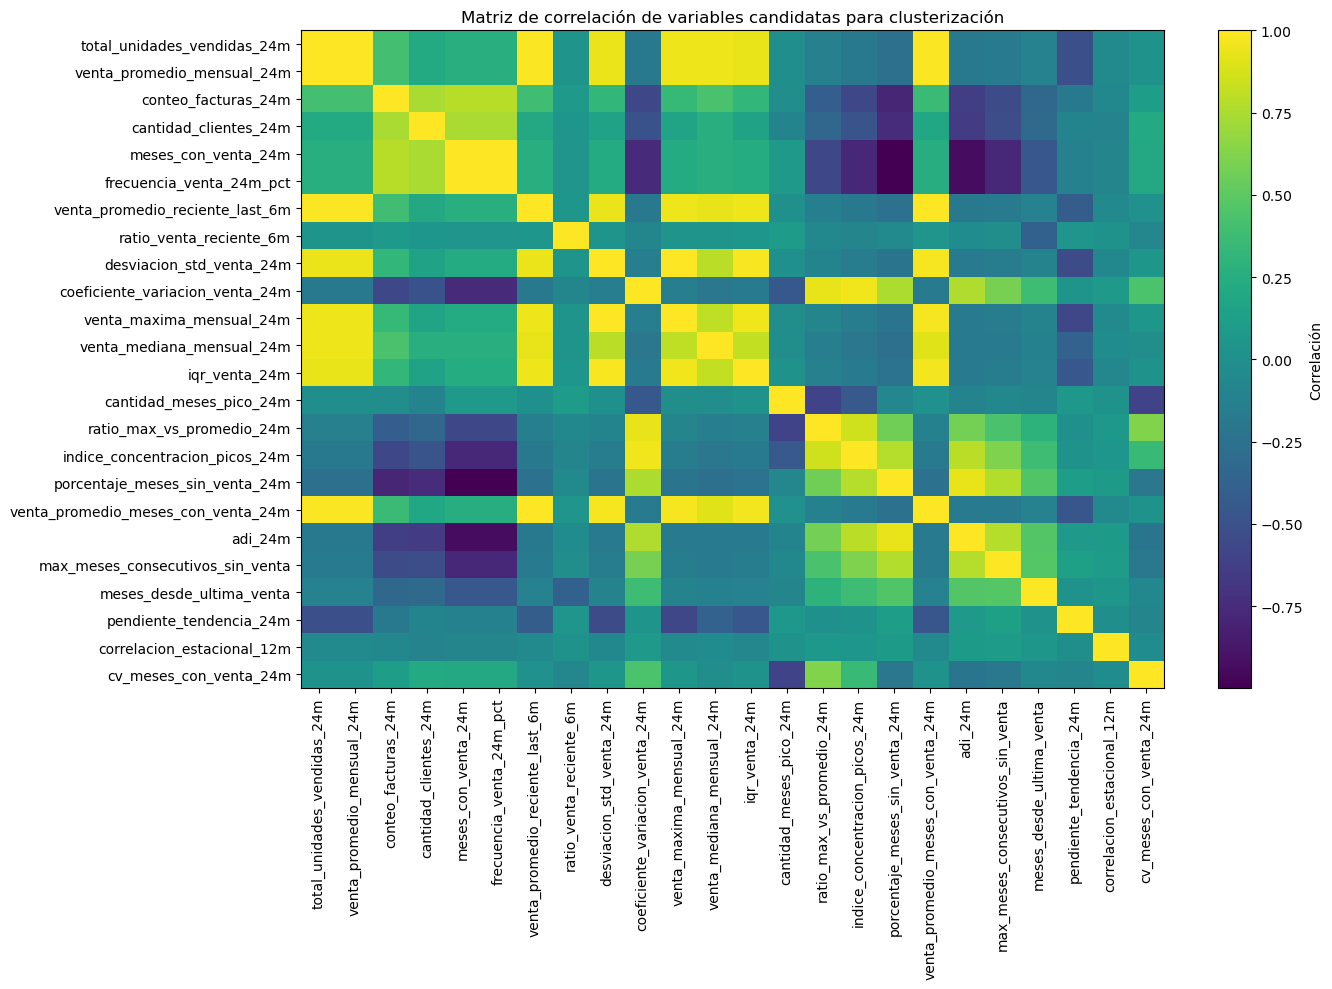

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Matriz base
df_corr = df[ventas_variables_cluster_all].copy()

# Asegurar valores numéricos
df_corr = df_corr.apply(pd.to_numeric, errors="coerce").fillna(0)

# Calcular correlación
corr_matrix = df_corr.corr()

# Visualizar matriz
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Matriz de correlación de variables candidatas para clusterización")
plt.tight_layout()
plt.show()

In [64]:
# Convertir matriz de correlación en pares
corr_abs = corr_matrix.abs()

# Tomar solo triángulo superior para evitar duplicados
upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# Extraer pares con correlación alta
pares_alta_correlacion = (
    upper.stack()
    .reset_index()
)

pares_alta_correlacion.columns = [
    "variable_1",
    "variable_2",
    "correlacion_abs"
]

pares_alta_correlacion = pares_alta_correlacion[
    pares_alta_correlacion["correlacion_abs"] >= 0.85
].sort_values("correlacion_abs", ascending=False)

pares_alta_correlacion

,variable_1,variable_2,correlacion_abs
1,total_unidades_vendidas_24m,venta_promedio_mensual_24m,1.000000
101,meses_con_venta_24m,frecuencia_venta_24m_pct,1.000000
136,frecuencia_venta_24m_pct,porcentaje_meses_sin_venta_24m,0.998935
112,meses_con_venta_24m,porcentaje_meses_sin_venta_24m,0.998935
202,desviacion_std_venta_24m,venta_maxima_mensual_24m,0.994209
161,venta_promedio_reciente_last_6m,venta_promedio_meses_con_venta_24m,0.993365
30,venta_promedio_mensual_24m,venta_promedio_reciente_last_6m,0.990331
6,total_unidades_vendidas_24m,venta_promedio_reciente_last_6m,0.990331
17,total_unidades_vendidas_24m,venta_promedio_meses_con_venta_24m,0.985527
41,venta_promedio_mensual_24m,venta_promedio_meses_con_venta_24m,0.985527


In [66]:
import numpy as np
import pandas as pd

def eliminar_variables_alta_correlacion(df, variables, umbral=0.85):
    """
    Elimina variables altamente correlacionadas según un umbral definido.

    Parámetros:
    df : DataFrame original.
    variables : lista de variables candidatas para clusterización.
    umbral : correlación absoluta máxima permitida. 
             Ejemplo: 0.85 elimina variables con correlación >= 0.85.

    Retorna:
    variables_finales : lista de variables sin alta redundancia.
    variables_eliminadas : lista de variables eliminadas.
    pares_correlacionados : DataFrame con pares de variables altamente correlacionadas.
    """

    # ========================================================
    # 1. Crear copia solo con variables candidatas
    # ========================================================

    df_corr = df[variables].copy()

    # Asegurar que todas las variables sean numéricas
    df_corr = df_corr.apply(pd.to_numeric, errors="coerce").fillna(0)

    # ========================================================
    # 2. Calcular matriz de correlación absoluta
    # ========================================================

    corr_matrix = df_corr.corr().abs()

    # ========================================================
    # 3. Tomar solo el triángulo superior de la matriz
    # ========================================================
    # Esto evita evaluar dos veces el mismo par:
    # variable A vs variable B
    # variable B vs variable A
    # ========================================================

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # ========================================================
    # 4. Identificar variables a eliminar
    # ========================================================
    # Si una variable tiene correlación mayor al umbral con alguna
    # variable anterior, se marca para eliminación.
    # ========================================================

    variables_eliminadas = [
        column for column in upper.columns
        if any(upper[column] >= umbral)
    ]

    variables_finales = [
        variable for variable in variables
        if variable not in variables_eliminadas
    ]

    # ========================================================
    # 5. Crear tabla de pares altamente correlacionados
    # ========================================================

    pares_correlacionados = (
        upper.stack()
        .reset_index()
    )

    pares_correlacionados.columns = [
        "variable_1",
        "variable_2",
        "correlacion_abs"
    ]

    pares_correlacionados = pares_correlacionados[
        pares_correlacionados["correlacion_abs"] >= umbral
    ].sort_values("correlacion_abs", ascending=False)

    return variables_finales, variables_eliminadas, pares_correlacionados

In [67]:
variables_finales, variables_eliminadas, pares_correlacionados = eliminar_variables_alta_correlacion(
    df=df,
    variables=ventas_variables_cluster_all,
    umbral=0.85
)

In [69]:
print(f"Variables originales: {len(ventas_variables_cluster_all)}")
print(f"Variables finales: {len(variables_finales)}")
print(f"Variables eliminadas: {len(variables_eliminadas)}")

print("\nVariables eliminadas por alta correlación:")
print(variables_eliminadas)

print("\nVariables finales sugeridas para cluster :")
print(variables_finales)

Variables originales: 24
Variables finales: 12
Variables eliminadas: 12

Variables eliminadas por alta correlación:
['venta_promedio_mensual_24m', 'frecuencia_venta_24m_pct', 'venta_promedio_reciente_last_6m', 'desviacion_std_venta_24m', 'venta_maxima_mensual_24m', 'venta_mediana_mensual_24m', 'iqr_venta_24m', 'ratio_max_vs_promedio_24m', 'indice_concentracion_picos_24m', 'porcentaje_meses_sin_venta_24m', 'venta_promedio_meses_con_venta_24m', 'adi_24m']

Variables finales sugeridas para cluster :
['total_unidades_vendidas_24m', 'conteo_facturas_24m', 'cantidad_clientes_24m', 'meses_con_venta_24m', 'ratio_venta_reciente_6m', 'coeficiente_variacion_venta_24m', 'cantidad_meses_pico_24m', 'max_meses_consecutivos_sin_venta', 'meses_desde_ultima_venta', 'pendiente_tendencia_24m', 'correlacion_estacional_12m', 'cv_meses_con_venta_24m']


# Análisis exploratorio de variables para clusterización

Antes de aplicar los algoritmos de clusterización, se realizará un análisis exploratorio de las variables seleccionadas para comprender el comportamiento matemático de los artículos que aplican a forecast.

El objetivo de esta sección es capturar una fotografía inicial del conjunto de datos, identificando patrones de frecuencia, intermitencia, recencia, variabilidad, tendencia, concentración de picos y posible estacionalidad. Este análisis permitirá interpretar mejor qué tipo de comportamientos de demanda existen antes de agrupar los artículos en clusters.

Esta etapa es importante porque la clusterización no debe aplicarse como una caja negra. Primero es necesario entender qué características dominan el historial de venta y cómo se distribuyen los artículos según sus propiedades matemáticas de demanda.


## 1. Preparar DataFrame de análisis

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Preparar DataFrame para EDA de artículos aplicables a forecast
# ============================================================

df_eda = df[df["aplica_forecast"] == True].copy()

variables_cluster_final = [
    "total_unidades_vendidas_24m",
    "conteo_facturas_24m",
    "cantidad_clientes_24m",
    "meses_con_venta_24m",
    "ratio_venta_reciente_6m",
    "coeficiente_variacion_venta_24m",
    "cantidad_meses_pico_24m",
    "max_meses_consecutivos_sin_venta",
    "meses_desde_ultima_venta",
    "pendiente_tendencia_24m",
    "correlacion_estacional_12m",
    "cv_meses_con_venta_24m"
]

# Asegurar variables numéricas
df_eda[variables_cluster_final] = (
    df_eda[variables_cluster_final]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(f"Artículos aplicables a forecast: {len(df_eda)}")

Artículos aplicables a forecast: 429


## 2. Clasificar estacionalidad

In [76]:
# ============================================================
# 2. Clasificación de estacionalidad
# ============================================================

condiciones = [
    df_eda["correlacion_estacional_12m"].isna(),
    df_eda["correlacion_estacional_12m"] >= 0.70,
    df_eda["correlacion_estacional_12m"] >= 0.40,
    df_eda["correlacion_estacional_12m"] >= 0.20
]

resultados = [
    "No evaluable",
    "Estacionalidad fuerte",
    "Estacionalidad moderada",
    "Estacionalidad débil"
]

df_eda["clasificacion_estacionalidad_24m"] = np.select(
    condiciones,
    resultados,
    default="Sin estacionalidad clara"
)

In [75]:
conteo_estacionalidad = (
    df_eda["clasificacion_estacionalidad_24m"]
    .value_counts()
    .reset_index()
)

conteo_estacionalidad.columns = [
    "clasificacion_estacionalidad_24m",
    "cantidad_articulos"
]

conteo_estacionalidad["porcentaje"] = round(
    (
        conteo_estacionalidad["cantidad_articulos"] /
        conteo_estacionalidad["cantidad_articulos"].sum()
    ) * 100,
    2
)

conteo_estacionalidad

,clasificacion_estacionalidad_24m,cantidad_articulos,porcentaje
0,Sin estacionalidad clara,331,77.16
1,Estacionalidad débil,52,12.12
2,Estacionalidad moderada,36,8.39
3,Estacionalidad fuerte,10,2.33


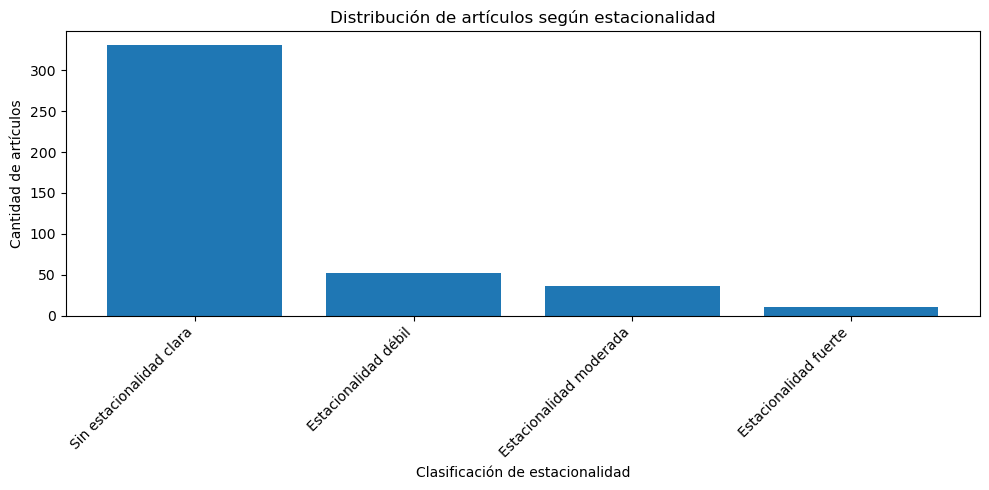

In [77]:
plt.figure(figsize=(10, 5))

plt.bar(
    conteo_estacionalidad["clasificacion_estacionalidad_24m"],
    conteo_estacionalidad["cantidad_articulos"]
)

plt.title("Distribución de artículos según estacionalidad")
plt.xlabel("Clasificación de estacionalidad")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Clasificar frecuencia de venta

In [79]:
# ============================================================
# 3. Clasificación de frecuencia de venta
# ============================================================

condiciones = [
    df_eda["meses_con_venta_24m"] >= 18,
    df_eda["meses_con_venta_24m"] >= 12,
    df_eda["meses_con_venta_24m"] >= 6,
    df_eda["meses_con_venta_24m"] >= 3
]

resultados = [
    "Alta frecuencia",
    "Frecuencia media",
    "Baja frecuencia",
    "Frecuencia esporádica"
]

df_eda["clasificacion_frecuencia_venta_24m"] = np.select(
    condiciones,
    resultados,
    default="Muy baja frecuencia"
)

In [80]:
conteo_frecuencia = (
    df_eda["clasificacion_frecuencia_venta_24m"]
    .value_counts()
    .reset_index()
)

conteo_frecuencia.columns = [
    "clasificacion_frecuencia_venta_24m",
    "cantidad_articulos"
]

conteo_frecuencia

,clasificacion_frecuencia_venta_24m,cantidad_articulos
0,Baja frecuencia,250
1,Frecuencia media,114
2,Alta frecuencia,65


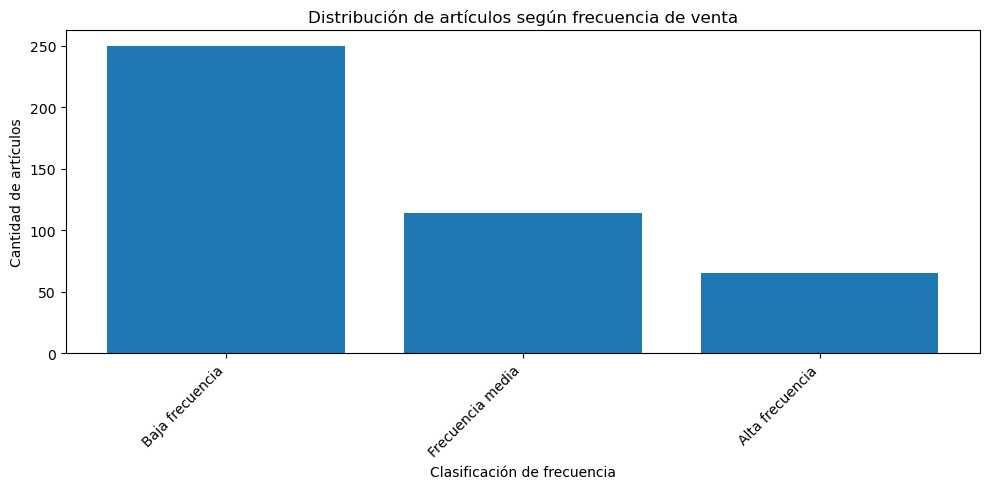

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(
    conteo_frecuencia["clasificacion_frecuencia_venta_24m"],
    conteo_frecuencia["cantidad_articulos"]
)

plt.title("Distribución de artículos según frecuencia de venta")
plt.xlabel("Clasificación de frecuencia")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. Distribución de artículos por clasificación estacional
# ============================================================

conteo_estacionalidad = (
    df["clasificacion_estacionalidad_24m"]
    .value_counts(dropna=False)
    .reset_index()
)

conteo_estacionalidad.columns = [
    "clasificacion_estacionalidad_24m",
    "cantidad_articulos"
]

conteo_estacionalidad

,clasificacion_estacionalidad_24m,cantidad_articulos
0,Sin estacionalidad clara,331
1,Estacionalidad débil,52
2,Estacionalidad moderada,36
3,Estacionalidad fuerte,10


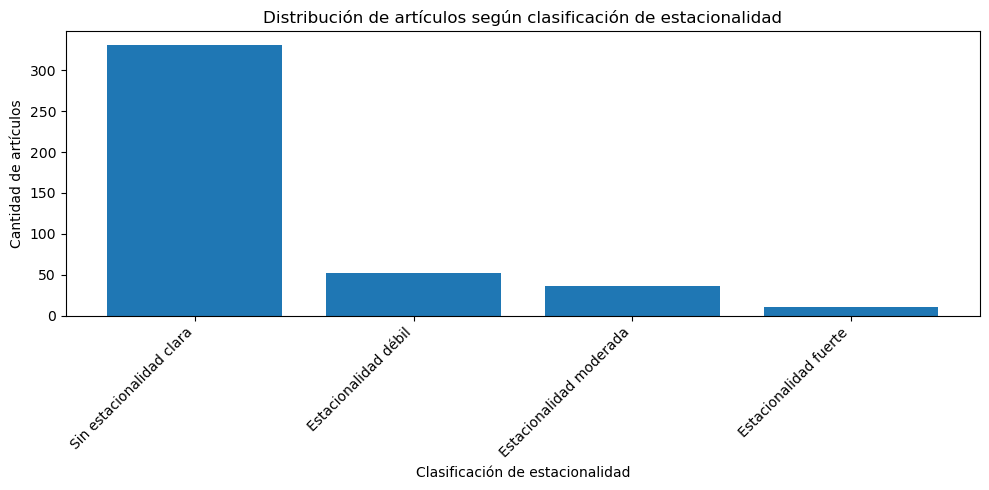

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    conteo_estacionalidad["clasificacion_estacionalidad_24m"],
    conteo_estacionalidad["cantidad_articulos"]
)

plt.title("Distribución de artículos según clasificación de estacionalidad")
plt.xlabel("Clasificación de estacionalidad")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
conteo_estacionalidad["porcentaje"] = (
    conteo_estacionalidad["cantidad_articulos"] /
    conteo_estacionalidad["cantidad_articulos"].sum()
) * 100

conteo_estacionalidad

,clasificacion_estacionalidad_24m,cantidad_articulos,porcentaje
0,Sin estacionalidad clara,331,77.156177
1,Estacionalidad débil,52,12.121212
2,Estacionalidad moderada,36,8.391608
3,Estacionalidad fuerte,10,2.331002


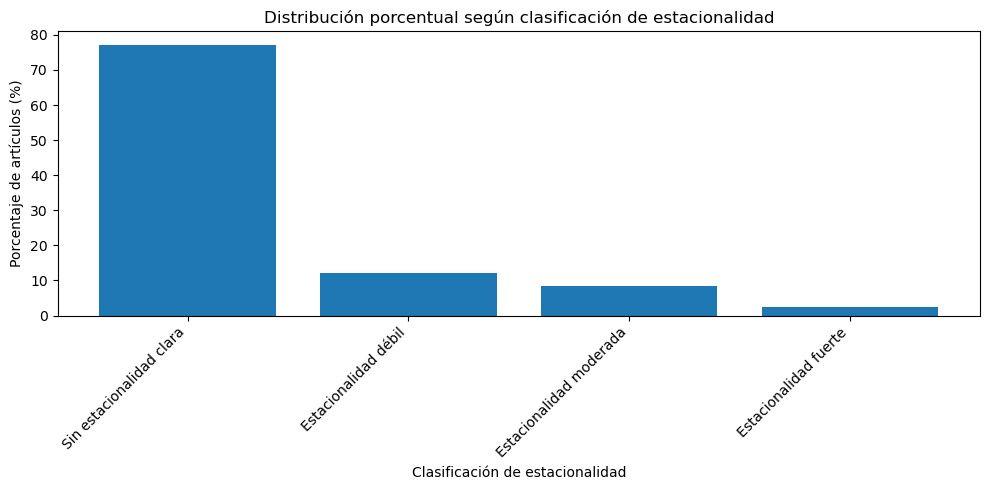

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    conteo_estacionalidad["clasificacion_estacionalidad_24m"],
    conteo_estacionalidad["porcentaje"]
)

plt.title("Distribución porcentual según clasificación de estacionalidad")
plt.xlabel("Clasificación de estacionalidad")
plt.ylabel("Porcentaje de artículos (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

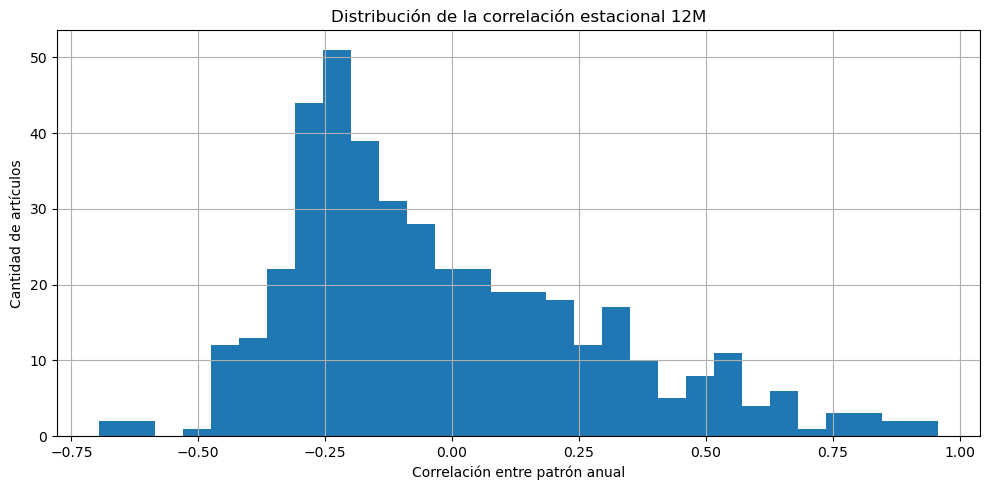

In [ ]:
plt.figure(figsize=(10, 5))

df["correlacion_estacional_12m"].dropna().hist(bins=30)

plt.title("Distribución de la correlación estacional 12M")
plt.xlabel("Correlación entre patrón anual")
plt.ylabel("Cantidad de artículos")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

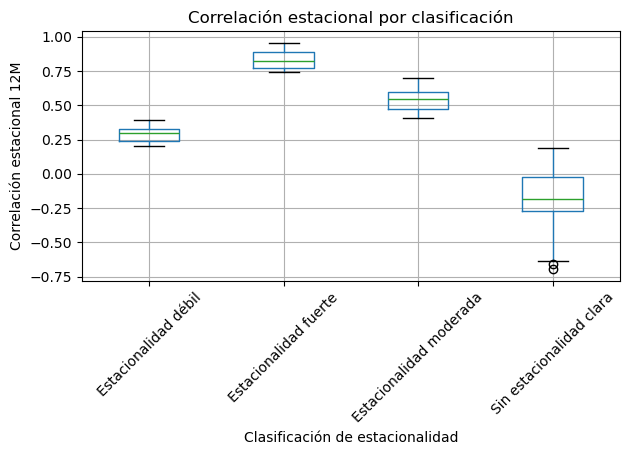

In [ ]:
plt.figure(figsize=(10, 5))

df.boxplot(
    column="correlacion_estacional_12m",
    by="clasificacion_estacionalidad_24m",
    rot=45
)

plt.title("Correlación estacional por clasificación")
plt.suptitle("")
plt.xlabel("Clasificación de estacionalidad")
plt.ylabel("Correlación estacional 12M")
plt.tight_layout()
plt.show()

In [ ]:
def clasificar_tipo_demanda_syntetos(adi, cv2):
    if adi < 1.32 and cv2 < 0.49:
        return "Smooth"
    elif adi >= 1.32 and cv2 < 0.49:
        return "Intermittent"
    elif adi < 1.32 and cv2 >= 0.49:
        return "Erratic"
    else:
        return "Lumpy"

In [ ]:
df["cv2_meses_con_venta_24m"] = df["cv_meses_con_venta_24m"] ** 2

df["tipo_demanda_syntetos"] = df.apply(
    lambda row: clasificar_tipo_demanda_syntetos(
        row["adi_24m"],
        row["cv2_meses_con_venta_24m"]
    ),
    axis=1
)